In [1]:
from pathlib import Path
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')
sns.set_theme(style='whitegrid')


In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / 'data/raw/cresht2606_vietnam-real-estate-datasets-catalyst'
CLEAN_FILE = PROJECT_ROOT / 'data/processed/cresht2606_regression_cleaned.csv'
TARGET_COLUMNS = ['price_million_vnd', 'area_m2', 'timeline_hours']

FAST_MODE = True
MAX_ROWS_PER_RAW_FILE = 30000 if FAST_MODE else None
MAX_ROWS_CLEAN = 30000 if FAST_MODE else None

COLOR_RAW = '#1f77b4'
COLOR_CLEAN = '#ff7f0e'


In [3]:
def _read_csv(path: Path, columns=None, nrows=None):
    if columns is None:
        return pd.read_csv(path, encoding='utf-8-sig', nrows=nrows, low_memory=False)
    keep = set(columns)
    return pd.read_csv(path, encoding='utf-8-sig', usecols=lambda c: c in keep, nrows=nrows, low_memory=False)


def _coerce_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for col in cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
    return out


def load_raw_dataset(input_dir: Path, columns=None, max_rows_per_file=None, verbose=True) -> pd.DataFrame:
    files = sorted(input_dir.glob('*.csv'))
    if not files:
        raise FileNotFoundError(f'No CSV files in: {input_dir}')

    parts = []
    for path in files:
        if verbose:
            print(f'[raw] reading {path.name} ...')
        part = _read_csv(path, columns=columns, nrows=max_rows_per_file)
        parts.append(part)
        if verbose:
            print(f'[raw] {path.name}: {len(part):,} rows')

    out = pd.concat(parts, ignore_index=True)
    return _coerce_numeric(out, TARGET_COLUMNS)


def load_clean_dataset(clean_file: Path, columns=None, max_rows=None, verbose=True) -> pd.DataFrame:
    if not clean_file.exists():
        raise FileNotFoundError(f'Clean file not found: {clean_file}')
    if verbose:
        print(f'[clean] reading {clean_file.name} ...')
    out = _read_csv(clean_file, columns=columns, nrows=max_rows)
    out = _coerce_numeric(out, TARGET_COLUMNS)
    if verbose:
        print(f'[clean] {clean_file.name}: {len(out):,} rows')
    return out


In [4]:
def _common_hist_range(raw_s: pd.Series, clean_s: pd.Series):
    combined = pd.concat([raw_s, clean_s], ignore_index=True)
    if combined.empty:
        return None
    q01 = combined.quantile(0.01)
    q99 = combined.quantile(0.99)
    if pd.isna(q01) or pd.isna(q99) or q01 == q99:
        return None
    return (q01, q99)


def plot_hist_raw_vs_clean(
    raw_df: pd.DataFrame,
    clean_df: pd.DataFrame,
    col: str,
    bins: int = 60,
    use_log1p: bool = False,
):
    if col not in raw_df.columns or col not in clean_df.columns:
        print(f'Skip {col}: missing in raw or clean')
        return

    raw_s = pd.to_numeric(raw_df[col], errors='coerce').dropna()
    clean_s = pd.to_numeric(clean_df[col], errors='coerce').dropna()

    if raw_s.empty or clean_s.empty:
        print(f'Skip {col}: no numeric values in raw or clean')
        return

    x_label = col
    plot_col_name = col

    if use_log1p:
        raw_s = np.log1p(raw_s.clip(lower=0))
        clean_s = np.log1p(clean_s.clip(lower=0))
        x_label = f'log1p({col})'
        plot_col_name = f'{col} (log1p)'

    hist_range = _common_hist_range(raw_s, clean_s)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

    sns.histplot(raw_s, bins=bins, binrange=hist_range, stat='count', element='step',
                 fill=True, alpha=0.35, color=COLOR_RAW, ax=axes[0])
    axes[0].set_title(f'Raw: {plot_col_name}')
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel('Count')

    sns.histplot(clean_s, bins=bins, binrange=hist_range, stat='count', element='step',
                 fill=True, alpha=0.35, color=COLOR_CLEAN, ax=axes[1])
    axes[1].set_title(f'Clean: {plot_col_name}')
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel('')

    fig.suptitle(f'Histogram Comparison by Column: {plot_col_name}', y=1.02)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


In [5]:
start = time.time()
raw_df = load_raw_dataset(RAW_DIR, columns=TARGET_COLUMNS, max_rows_per_file=MAX_ROWS_PER_RAW_FILE, verbose=True)
clean_df = load_clean_dataset(CLEAN_FILE, columns=TARGET_COLUMNS, max_rows=MAX_ROWS_CLEAN, verbose=True)

print(f'raw rows: {len(raw_df):,}')
print(f'clean rows: {len(clean_df):,}')
print(f'load time: {time.time() - start:.2f}s')
if FAST_MODE:
    print('FAST_MODE=True')


[raw] reading house_buying_dec29th_2025.csv ...
[raw] house_buying_dec29th_2025.csv: 30,000 rows
[raw] reading house_rental_dec29th_2025.csv ...
[raw] house_rental_dec29th_2025.csv: 4,808 rows
[clean] reading cresht2606_regression_cleaned.csv ...
[clean] cresht2606_regression_cleaned.csv: 30,000 rows
raw rows: 34,808
clean rows: 30,000
load time: 0.40s
FAST_MODE=True


In [6]:
print('Non-null counts (raw vs clean):')
for col in TARGET_COLUMNS:
    if col in raw_df.columns and col in clean_df.columns:
        r = int(raw_df[col].notna().sum())
        c = int(clean_df[col].notna().sum())
        print(f'{col:18s} raw_nonnull={r:7d} clean_nonnull={c:7d}')


Non-null counts (raw vs clean):
price_million_vnd  raw_nonnull=  33943 clean_nonnull=  30000
area_m2            raw_nonnull=  26828 clean_nonnull=  24043
timeline_hours     raw_nonnull=  34808 clean_nonnull=  30000


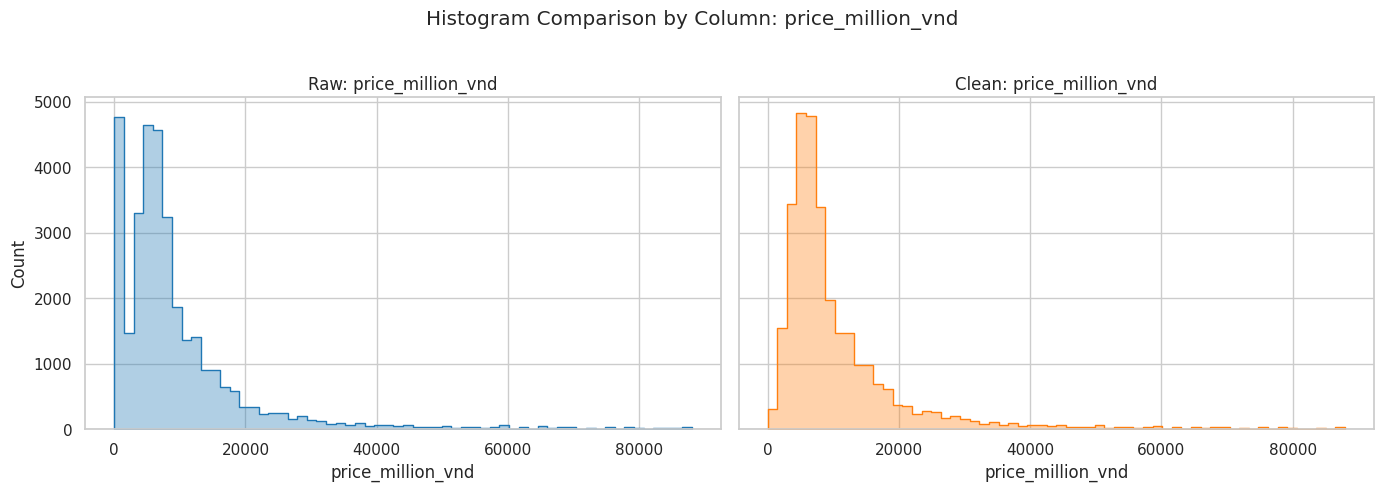

In [7]:
plot_hist_raw_vs_clean(raw_df, clean_df, 'price_million_vnd')


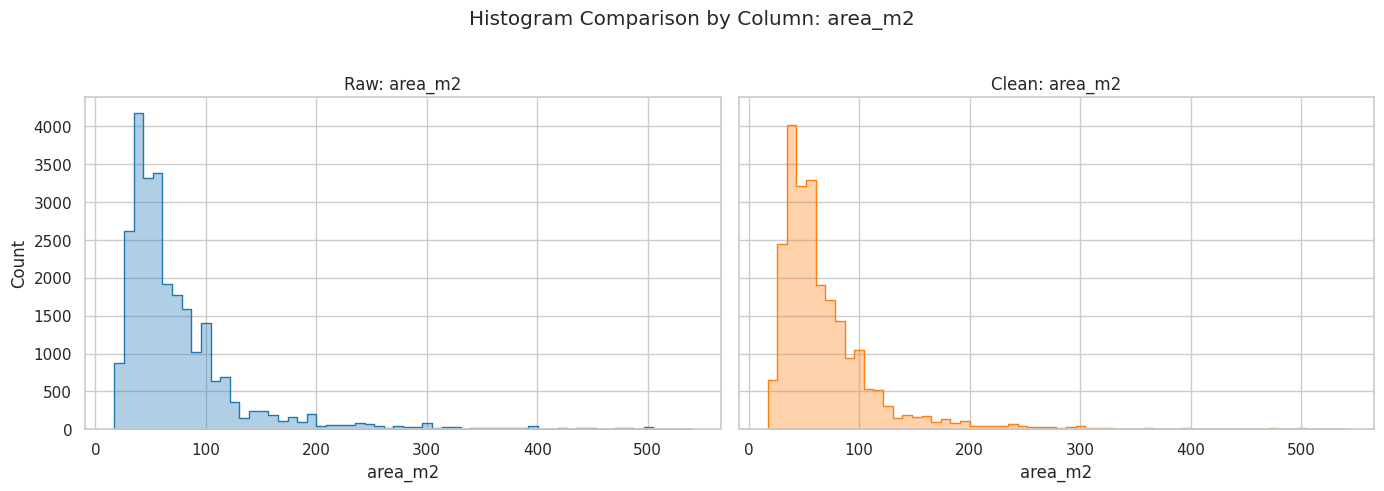

In [8]:
plot_hist_raw_vs_clean(raw_df, clean_df, 'area_m2')


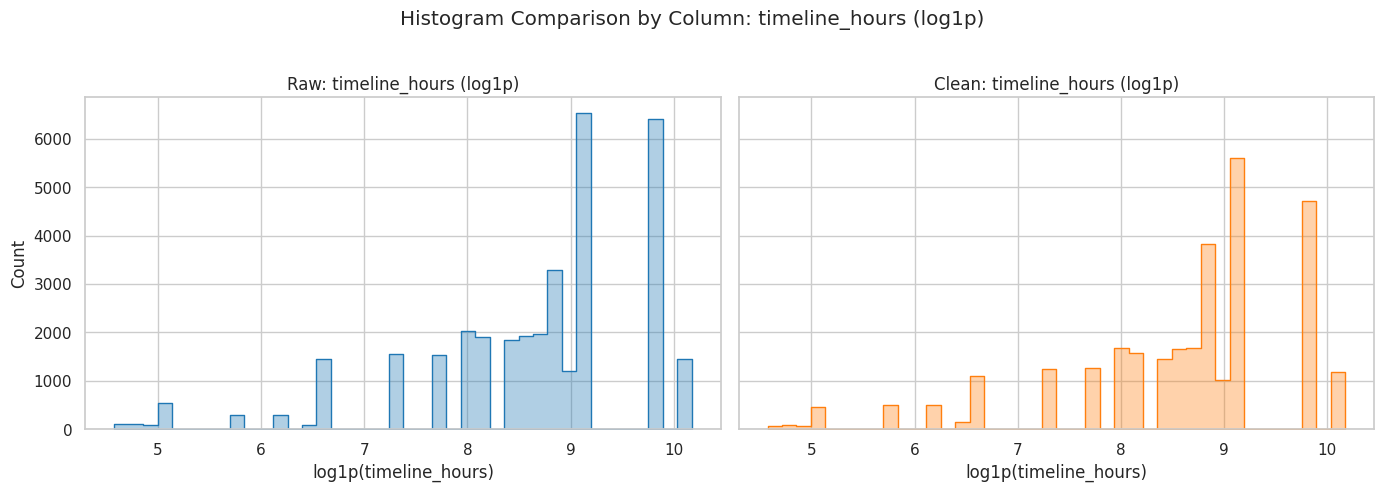

In [9]:
plot_hist_raw_vs_clean(raw_df, clean_df, 'timeline_hours', bins=40, use_log1p=True)


In [47]:
if FAST_MODE:
    print('Set FAST_MODE=False and Run All for final conclusions.')
else:
    for col in TARGET_COLUMNS:
        if col not in raw_df.columns or col not in clean_df.columns:
            continue
        rq = raw_df[col].dropna().quantile([0.5, 0.9, 0.99]).to_dict()
        cq = clean_df[col].dropna().quantile([0.5, 0.9, 0.99]).to_dict()
        print(f'\n{col}')
        print('raw  ', {k: round(v, 3) for k, v in rq.items()})
        print('clean', {k: round(v, 3) for k, v in cq.items()})


Set FAST_MODE=False and Run All for final conclusions.
